In [1]:
import pandas as pd
from pathlib import Path

dfs = []
for i in range(1999, 2025):
    path = f"StateDrugUtilizationData{i}.csv"
    if Path(path).exists():
        dfs.append(pd.read_csv(path))
    else:
        print(f"Missing: {path}")

combined_df = pd.concat(dfs, ignore_index=True)

/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_72052/3600261723.py:8: DtypeWarning: Columns (0: NDC) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_72052/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Package Size) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_72052/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Product Code, 2: Package Size) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_72052/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Product Code) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))


In [2]:
len(combined_df)

94966348

In [3]:
combined_df = combined_df.sort_values('Product Name')

In [4]:
combined_df.tail(30)

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
1237213,FFSU,MT,186045131,186,451,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237214,FFSU,MT,186045158,186,451,58,1999,1,False,NaN,575.0,17.0,567.01,0.0,0.0
1237215,FFSU,MT,186045231,186,452,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237216,FFSU,MT,186045258,186,452,58,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237217,FFSU,MT,186060631,186,606,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237219,FFSU,MT,186074231,186,742,31,1999,1,False,NaN,5033.0,160.0,18208.37,0.0,0.0
1237220,FFSU,MT,186074282,186,742,82,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237221,FFSU,MT,186074331,186,743,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237249,FFSU,MT,187320426,187,3204,26,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1239139,FFSU,MT,597005205,597,52,5,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(combined_df.shape)
print(combined_df['Labeler Code'].dtype)
print(combined_df[combined_df['Labeler Code'] == '00074']['Product Name'].unique())

(94966348, 15)
int64
<StringArray>
[]
Length: 0, dtype: str


In [6]:
lupron_rows = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
]

print(lupron_rows['Product Name'].unique())
print(lupron_rows.shape)

<StringArray>
['LUPRON DEP']
Length: 1, dtype: str
(41638, 15)


In [7]:
# Filter to LUPRON DEPOT only
lupron_df = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
].copy()

# Check what you have
print(lupron_df['Year'].unique())
print(lupron_df['State'].unique())
print(lupron_df['Suppression Used'].value_counts())

[2020 2010 2018 2017 2015 2024 2012 2019 2016 2022 2021 2023 2013 2011
 2009 2014]
<StringArray>
['ID', 'AK', 'PA', 'MA', 'FL', 'TX', 'MN', 'NV', 'GA', 'CA', 'MI', 'OK', 'SC',
 'ND', 'XX', 'NJ', 'CT', 'NE', 'NH', 'AZ', 'MS', 'AL', 'NY', 'VA', 'WV', 'KS',
 'WA', 'WY', 'ME', 'DC', 'NC', 'SD', 'MO', 'IA', 'MD', 'AR', 'WI', 'OH', 'PR',
 'NM', 'DE', 'RI', 'MT', 'VT', 'LA', 'KY', 'IL', 'TN', 'IN', 'HI', 'CO', 'OR',
 'UT']
Length: 53, dtype: str
Suppression Used
True     22499
False    19139
Name: count, dtype: int64


In [8]:
# Drop unknown state and suppressed rows
lupron_clean = lupron_df[
    (lupron_df['Suppression Used'] == False) &
    (~lupron_df['State'].isin(['XX']))
].copy()

# Aggregate to state-year
lupron_agg = (
    lupron_clean
    .groupby(['State', 'Year'])['Number of Prescriptions']
    .sum()
    .reset_index()
)

# Check result
print(lupron_agg.shape)
print(lupron_agg.head(10))
print(lupron_agg['Year'].nunique(), 'years')
print(lupron_agg['State'].nunique(), 'states')

(770, 3)
  State  Year  Number of Prescriptions
0    AK  2009                     13.0
1    AK  2010                     27.0
2    AK  2011                     11.0
3    AK  2012                     44.0
4    AK  2013                     40.0
5    AK  2014                     14.0
6    AK  2015                     11.0
7    AK  2016                     20.0
8    AK  2017                     76.0
9    AK  2018                     70.0
16 years
52 states


In [9]:
!pip install pymc arviz numpy

In [10]:
!pip install "numpy<2.0" pymc arviz

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
INFO: pip is looking at multiple versions of pytensor to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-3.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pandas-2.3.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pandas-2.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pandas-2.2.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (89 kB)
INFO: pip is still looking at multiple versions of pytensor to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas-2.2.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (

In [11]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# Encode state as integer index
lupron_agg['state_idx'] = pd.Categorical(lupron_agg['State']).codes
n_states = lupron_agg['state_idx'].nunique()

# Center year
lupron_agg['year_centered'] = lupron_agg['Year'] - lupron_agg['Year'].mean()

# Arrays for model
state_idx = lupron_agg['state_idx'].values
year_c = lupron_agg['year_centered'].values
y = lupron_agg['Number of Prescriptions'].values

with pm.Model() as hierarchical_model:

    # national level
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=500)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=200)

    mu_beta = pm.Normal('mu_beta', mu=0, sigma=50)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=25)

    #state-level parameters (partial pooling)
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_states)
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_states)

    # --- Expected value ---
    mu = alpha[state_idx] + beta[state_idx] * year_c

    # --- Likelihood ---
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=200)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma_obs, observed=y)

    # --- Sample ---
    trace = pm.sample(2000, tune=1000, target_accept=0.9, 
                      return_inferencedata=True, random_seed=42)

 Progress                   Draws   Divergences   Step size   Grad evals   Sampling Speed    Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━   2999    0             0.353       15           247.70 drawss/s   0:00:12   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2999    0             0.315       15           235.07 drawss/s   0:00:12   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2999    0             0.365       15           239.02 drawss/s   0:00:12   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2999    0             0.340       15           249.80 drawss/s   0:00:12   0:00:00

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.


In [24]:
# Check convergence (r-hat should be close to 1.0 for all params)
print(az.summary(trace, var_names=['mu_alpha', 'mu_beta', 'sigma_alpha', 'sigma_beta']))

                 mean       sd   hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
mu_alpha      920.373  141.320  654.087  1186.551      0.992    1.875   
mu_beta        32.660    8.932   15.029    49.004      0.074    0.107   
sigma_alpha  1063.969   72.585  933.703  1202.883      0.589    0.886   
sigma_beta     59.883    6.200   48.899    72.129      0.054    0.069   

             ess_bulk  ess_tail  r_hat  
mu_alpha      20466.0    5063.0    1.0  
mu_beta       14474.0    6423.0    1.0  
sigma_alpha   15517.0    6060.0    1.0  
sigma_beta    13141.0    6267.0    1.0  


array([[<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'mu_beta'}>,
        <Axes: title={'center': 'mu_beta'}>]], dtype=object)

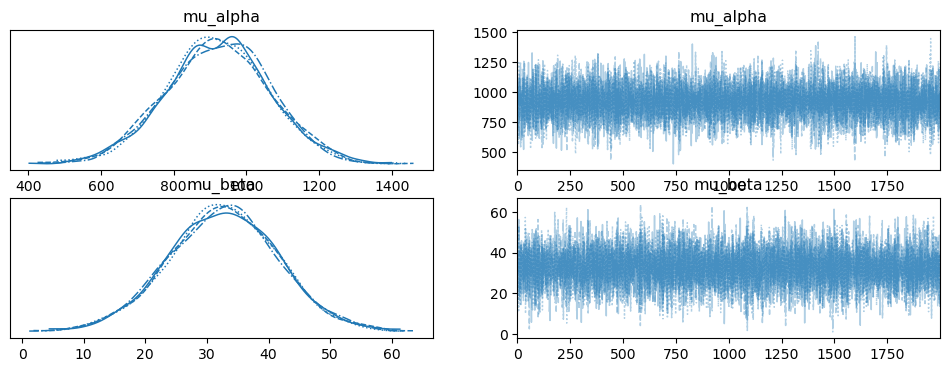

In [26]:
# Plot the national-level traces
az.plot_trace(trace, var_names=['mu_alpha', 'mu_beta'])

In [28]:
# State-level time trends
states = pd.Categorical(lupron_agg['State']).categories
beta_summary = az.summary(trace, var_names=['beta'])
beta_summary.index = [f'{s}' for s in states]
print(beta_summary[['mean', 'hdi_3%', 'hdi_97%']].sort_values('mean'))

       mean   hdi_3%  hdi_97%
AL  -24.331  -59.353   12.446
NC  -19.228  -54.949   18.691
TN  -17.537  -55.223   17.724
MO  -13.847  -49.807   21.741
OK   -6.669  -41.676   30.097
WV   -2.687  -39.407   34.530
WI   -1.070  -37.005   34.799
DE   -0.859  -37.545   35.415
VT    0.342  -36.783   36.282
PA    3.173  -31.998   39.935
KS    3.369  -35.631   42.697
ME    4.089  -32.990   38.845
UT    5.208  -45.929   49.117
RI    5.954  -34.042   45.234
SD    6.009  -49.422   63.035
ID    6.246  -31.416   40.806
DC    6.687  -33.210   47.089
SC    7.568  -28.531   46.195
AR    8.190  -28.696   45.438
MS    8.340  -27.398   45.732
MD   10.866  -25.554   47.865
ND   11.915  -48.869   74.727
WY   12.643  -54.515   77.079
NH   12.709  -23.681   48.800
MT   12.828  -38.635   61.744
AK   13.171  -23.619   50.123
NM   17.191  -22.618   56.190
IA   18.545  -19.228   53.514
KY   21.066  -16.290   55.004
MN   21.209  -15.971   58.527
HI   23.617  -21.998   67.519
NE   25.352  -16.735   62.217
NV   25.44

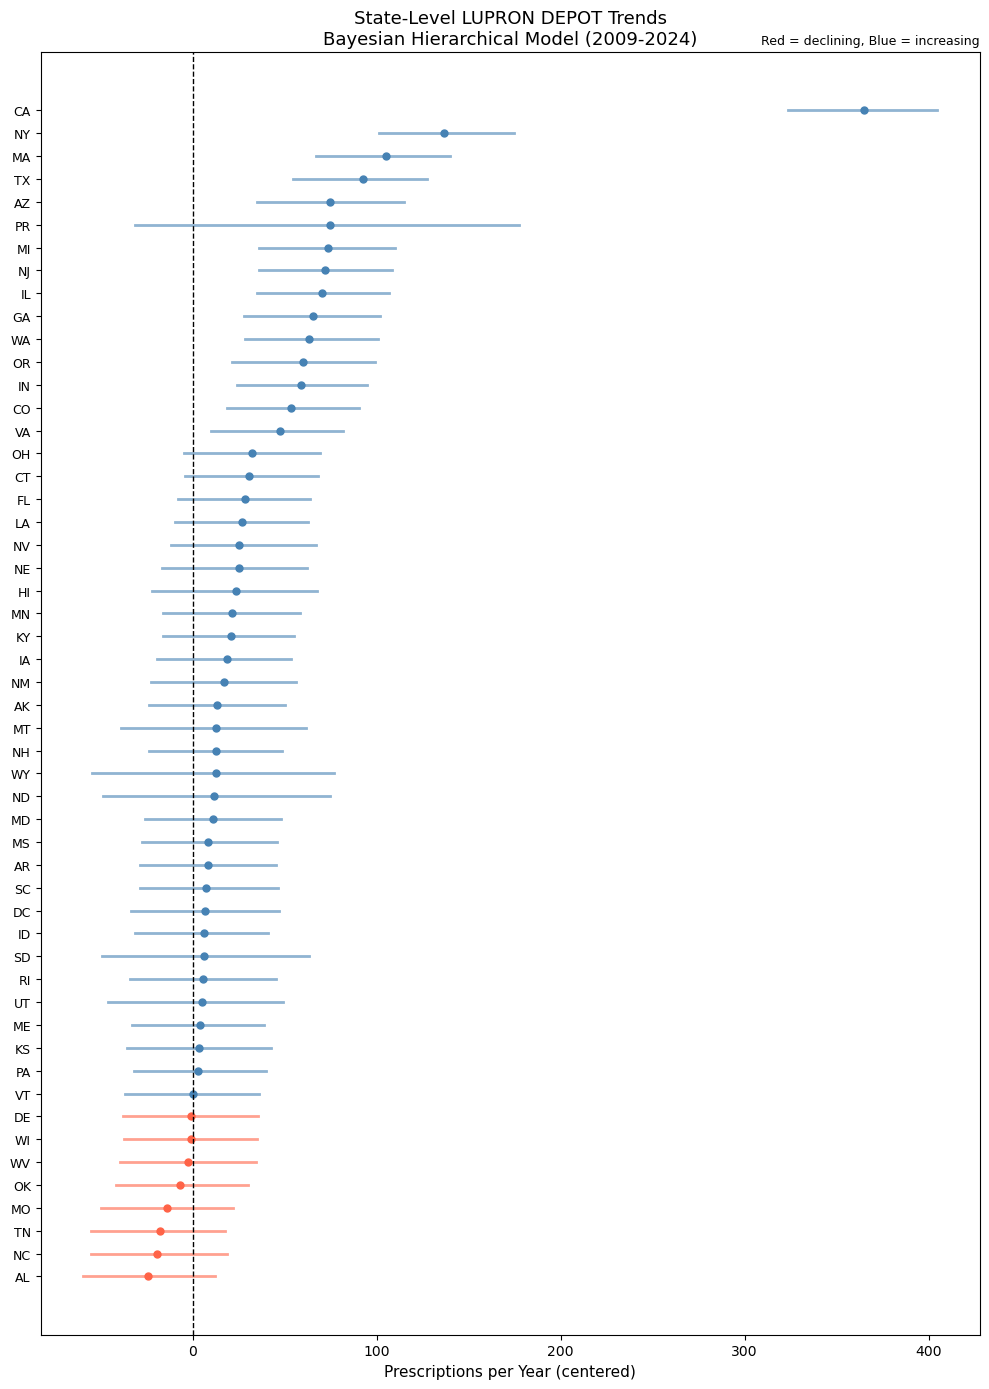

In [30]:
import matplotlib.pyplot as plt

# Rebuild summary with state labels
states = pd.Categorical(lupron_agg['State']).categories
beta_summary = az.summary(trace, var_names=['beta'])
beta_summary.index = [f'{s}' for s in states]
beta_sorted = beta_summary[['mean', 'hdi_3%', 'hdi_97%']].sort_values('mean')

# Plot
fig, ax = plt.subplots(figsize=(10, 14))

for i, (state, row) in enumerate(beta_sorted.iterrows()):
    color = 'steelblue' if row['mean'] > 0 else 'tomato'
    ax.plot([row['hdi_3%'], row['hdi_97%']], [i, i], color=color, alpha=0.6, linewidth=2)
    ax.plot(row['mean'], i, 'o', color=color, markersize=5)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(beta_sorted)))
ax.set_yticklabels(beta_sorted.index, fontsize=9)
ax.set_xlabel('Prescriptions per Year (centered)', fontsize=11)
ax.set_title('State-Level LUPRON DEPOT Trends\nBayesian Hierarchical Model (2009-2024)', fontsize=13)
ax.set_title('Red = declining, Blue = increasing', fontsize=9, loc='right')

plt.tight_layout()
plt.show()